In [1]:
from hapi import *
import numpy as np
from scipy import constants
import pycraf 
from astropy import units as u
from matplotlib import pyplot as plt

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
import re

def list_c_arrays(filepath):
    with open(filepath, 'r') as f:
        content = f.read()
    # Find all double arrays defined in the file
    pattern = r"double\s+([a-zA-Z0-9_]+)(?:\[.*?\])?\s*=\s*\{"
    return re.findall(pattern, content)

# Point this to your am-13.0/src directory
o2_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
print("Arrays in o2.c:", list_c_arrays(o2_file))

Arrays in o2.c: ['o2_abundance_tab', 'o2_mass_tab', 'o2_Qtab']


In [3]:
import re

def list_struct_arrays(filepath):
    """Scans a C file and returns the names of struct arrays."""
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Look for patterns like: [static] struct struct_type array_name[] = {
    pattern = r"struct\s+[a-zA-Z0-9_]+\s+([a-zA-Z0-9_]+)(?:\[.*?\])?\s*=\s*\{"
    return re.findall(pattern, content)

o2_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
print("Struct Arrays in o2.c:", list_struct_arrays(o2_file))

Struct Arrays in o2.c: []


In [4]:
def brute_force_physics_search(filepath, target_string):
    """Searches a file for a specific physical value and prints the surrounding context."""
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
            
        print(f"\n--- Searching inside {filepath.split('/')[-1]} ---")
        found = False
        for i, line in enumerate(lines):
            if target_string in line:
                print(f"Found target '{target_string}' at line {i+1}!")
                print("Context:")
                
                # Print 5 lines before and 5 lines after to see the array structure
                start = max(0, i - 5)
                end = min(len(lines), i + 6)
                for j in range(start, end):
                    prefix = ">> " if j == i else "   "
                    print(f"{prefix}Line {j+1}: {lines[j].strip()}")
                found = True
                break # Stop after the first match to avoid flooding the output
                
        if not found:
            print(f"Target '{target_string}' not found in this file.")
            
    except Exception as e:
        print(f"Could not read {filepath}: {e}")

# The paths to the source files
src_dir = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src'
o2_c_file = f'{src_dir}/o2.c'
o2_h_file = f'{src_dir}/o2.h'

# Search for the 118 GHz Oxygen line
brute_force_physics_search(o2_c_file, '118.75')
brute_force_physics_search(o2_h_file, '118.75')


--- Searching inside o2.c ---
Found target '118.75' at line 156!
Context:
   Line 151: {     66.836819, 6.589438e-26,  1792.665601,  1.0296e-03f,  1.0356e-03f,  0.80f,   0.0000e+00f,  1 },
   Line 152: {     67.369584, 3.063879e-26,  2043.413255,  1.0267e-03f,  1.0060e-03f,  0.80f,   0.0000e+00f,  1 },
   Line 153: {     67.900849, 1.343370e-26,  2310.376987,  1.0237e-03f,  1.0060e-03f,  0.80f,   0.0000e+00f,  1 },
   Line 154: {     68.430986, 5.555154e-27,  2593.513345,  1.0237e-03f,  1.0060e-03f,  0.80f,   0.0000e+00f,  1 },
   Line 155: {     68.960294, 2.168099e-27,  2892.776146,  1.0237e-03f,  1.0060e-03f,  0.80f,   0.0000e+00f,  1 },
>> Line 156: {    118.750341, 2.997925e-24,     0.000000,  1.6835e-03f,  1.6717e-03f,  0.80f,   0.0000e+00f,  1 },
   Line 157: };
   Line 158: 
   Line 159: const int o2_num_coupled_lines =
   Line 160: (int)(sizeof(o2_coupled_cat) / sizeof(cat_entry_t));
   Line 161: 

--- Searching inside o2.h ---
Target '118.75' not found in this file.


In [5]:
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})
#Let's plot k_total_O2 vs frequency
import matplotlib.pyplot as plt

In [6]:
import re
import numpy as np

def extract_struct_array(filepath, array_name):
    with open(filepath, 'r') as f:
        content = f.read()
    pattern = rf"{array_name}(?:\[.*?\])?\s*=\s*\{{([\s\S]*?)\}};"
    match = re.search(pattern, content)
    if not match: raise ValueError(f"Could not find {array_name}")
    
    rows = re.findall(r"\{([^}]+)\}", match.group(1))
    data = []
    for row in rows:
        row_clean = row.replace('f', '')
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", row_clean)
        data.append([float(n) for n in numbers])
    return np.array(data)

def get_perfect_o2_coupled_data(c_file_path):
    """
    Extracts both the catalog and coupling tables, merges them, 
    and converts all units to standard cm^-1 and atm.
    """
    # 1. Extract both arrays
    cat_matrix = extract_struct_array(c_file_path, 'o2_coupled_cat')
    mix_matrix = extract_struct_array(c_file_path, 'o2_line_coupling_coeffs')
    
    # Constants
    c  = 29.9792458 # GHz to cm^-1
    c2 = 1.4387770  # cm*K
    P0 = 1013.25    # atm to hPa/mbar
    
    # Mask for lines < 10 THz
    freq_GHz = cat_matrix[:, 0]
    mask = freq_GHz < 10000.0
    
    # --- TABLE 1: MAIN CATALOG (cat_entry_t) ---
    f0_cm   = cat_matrix[mask, 0] / c
    S_ref_cm = cat_matrix[mask, 1] / c  # [cm^2 * GHz] -> [cm^2 * cm^-1]
    E_low_cm = cat_matrix[mask, 2] / c2 # [K] -> back to [cm^-1] so our function works!
    gamma    = (cat_matrix[mask, 3] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    n_temp   = cat_matrix[mask, 5]
    
    # --- TABLE 2: MAKAROV COUPLING (line_coupling_table_entry_t) ---
    y0 = mix_matrix[mask, 0] * P0     # [1/hPa] -> [1/atm]
    y1 = mix_matrix[mask, 1] * P0
    v  = mix_matrix[mask, 2]          # y exponent
    g0 = mix_matrix[mask, 3] * (P0**2) # [1/hPa^2] -> [1/atm^2]
    g1 = mix_matrix[mask, 4] * (P0**2)
    d0 = (mix_matrix[mask, 6] * (P0**2)) / c # [GHz/hPa^2] -> [cm^-1/atm^2]
    d1 = (mix_matrix[mask, 7] * (P0**2)) / c
    
    return f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, y0, y1, v, g0, g1, d0, d1

# Execute!
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
(f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, 
 y0, y1, v, g0, g1, d0, d1) = get_perfect_o2_coupled_data(c_file_path)

def get_perfect_o2_uncoupled_data(c_file_path):
    """
    Extracts the uncoupled catalog table and converts all units 
    to standard cm^-1 and atm.
    """
    # 1. Extract the raw array
    cat_matrix = extract_struct_array(c_file_path, 'o2_uncoupled_cat')
    
    # Constants
    c  = 29.9792458 # GHz to cm^-1
    c2 = 1.4387770  # cm*K
    P0 = 1013.25    # atm to hPa
    
    # Mask for lines < 10 THz
    freq_GHz = cat_matrix[:, 0]
    mask = freq_GHz < 10000.0
    
    # Apply conversions
    f0_cm     = cat_matrix[mask, 0] / c
    S_ref_cm  = cat_matrix[mask, 1] / c   # [cm^2 * GHz] -> [cm^2 * cm^-1]
    E_low_cm  = cat_matrix[mask, 2] / c2  # [K] -> [cm^-1]
    gamma     = (cat_matrix[mask, 3] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    n_temp    = cat_matrix[mask, 5]
    delta_air = (cat_matrix[mask, 6] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    
    return f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, delta_air

# Execute!
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
(f0_u_cm, S_ref_u_cm, E_low_u_cm, gamma_u, 
 n_u, delta_u) = get_perfect_o2_uncoupled_data(c_file_path)

def compute_o2_line_strength(T, f0_cm, S_ref, E_lower):
    """
    Computes O2 line strength and compares the true Partition Sum vs the Linear Approximation.
    """
    T_ref = 296.0
    c2 = 1.4387770 
    
    # ---------------------------------------------------------
    # 1. The True Partition Function Ratio (HAPI)
    # Molecule 7 = O2, Isotope 1 = Main isotope
    # ---------------------------------------------------------
    Q_ref = partitionSum(7, 1, T_ref)
    Q_T = partitionSum(7, 1, T)
    Q_ratio_true = Q_ref / Q_T
    
    # ---------------------------------------------------------
    # 2. The Linear Approximation
    # ---------------------------------------------------------
    Q_ratio_approx = T_ref / T
    
    # Print the comparison
    print(f"At {T} K:")
    print(f"  True Q Ratio (HAPI) : {Q_ratio_true:.5f}")
    print(f"  Approx Q Ratio      : {Q_ratio_approx:.5f}")
    error_pct = abs(Q_ratio_true - Q_ratio_approx) / Q_ratio_true * 100
    print(f"  Partition Error     : {error_pct:.3f}%")
    
    # ---------------------------------------------------------
    # 3. The Rest of the Physics
    # ---------------------------------------------------------
    boltz_exponent = -c2 * E_lower * ((1.0 / T) - (1.0 / T_ref))
    boltz_factor = np.exp(boltz_exponent)
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    stim_ratio = stim_T / stim_ref
    
    # Calculate final S(T) using the TRUE HAPI ratio (for maximum accuracy right now)
    S_T_true = S_ref * Q_ratio_true * boltz_factor * stim_ratio
    S_T_approx = S_ref * Q_ratio_approx * boltz_factor * stim_ratio
    
    max_S_error = np.max(np.abs(S_T_true - S_T_approx) / S_T_true) * 100
    print(f"  Max Line Strength Error: {max_S_error:.3f}%\n")
    
    # Return the true one for now
    return S_T_true

def gross_shape(nu, nu0, gamma):
    """
    Computes the Gross line shape for uncoupled O2 lines.
    
    Inputs (must be in consistent units, e.g., cm^-1):
    nu    : Frequency grid (1D array, length N_nu)
    nu0   : Line centers (1D array, length N_lines)
    gamma : Pressure-broadened line widths (1D array, length N_lines)
    
    Returns:
    F_G   : 2D array of shape (N_nu, N_lines)
    """
    # Reshape arrays for matrix broadcasting
    nu_grid = nu[:, None]
    nu0_arr = nu0[None, :]
    gamma_arr = gamma[None, :]
    
    # Numerator: 4 * nu^2 * gamma
    numerator = 4.0 * (nu_grid**2) * gamma_arr
    
    # Denominator: (nu^2 - nu0^2)^2 + 4 * nu^2 * gamma^2
    denominator = ((nu_grid**2) - (nu0_arr**2))**2 + 4.0 * (nu_grid**2) * (gamma_arr**2)
    
    # Final Shape
    F_G = (1.0 / np.pi) * (numerator / denominator)
    
    return F_G


def vvw_coupled_shape(nu, nu0, gamma, P, T, Y0, Y1, g0, g1, dnu0, dnu1):
    """
    Computes the VVW_coupled line shape including line mixing and pressure modifications.
    
    Inputs:
    nu    : Frequency grid (1D array, length N_nu)
    nu0   : Line centers (1D array, length N_lines)
    gamma : Pressure-broadened line widths (1D array, length N_lines)
    P     : Dry air pressure
    T     : Ambient temperature [K]
    Y0, Y1, g0, g1, dnu0, dnu1: Empirical coupling coefficients (1D arrays, length N_lines)
    """
    T_ref = 300.0  # Reference temperature for coupling parameters (Marakov)
    
    # Reshape frequency grid
    nu_grid = nu[:, None]
    
    # Reshape all line parameters for broadcasting
    nu0_arr  = nu0[None, :]
    gamma_arr= gamma[None, :]
    Y0_arr   = Y0[None, :]
    Y1_arr   = Y1[None, :]
    g0_arr   = g0[None, :]
    g1_arr   = g1[None, :]
    dnu0_arr = dnu0[None, :]
    dnu1_arr = dnu1[None, :]
    
    # 1. Temperature Ratios
    theta = T_ref / T
    theta_minus_1 = theta - 1.0
    
    # 2. Calculate the temperature-dependent coupling parameters
    # 2. Calculate the temperature-dependent coupling parameters
    # MUST multiply by P (dry air pressure) to make Y dimensionless!
    Y = P * (Y0_arr + Y1_arr * theta_minus_1) * (theta**0.8)
    g = (g0_arr + g1_arr * theta_minus_1) * (theta**1.6)
    delta_nu = (dnu0_arr + dnu1_arr * theta_minus_1) * (theta**1.6)
    
    # 3. Pressure squared terms
    P2 = P**2
    g_term = 1.0 + g * P2
    dnu_term = delta_nu * P2
    
    # 4. Pre-factor
    prefactor = (1.0 / np.pi) * (nu_grid / nu0_arr)**2
    
    # 5. Delta terms (distance from line center, modified by pressure shift)
    delta_pos = nu_grid - nu0_arr - dnu_term
    delta_neg = nu_grid + nu0_arr + dnu_term
    
    # 6. Resonance Terms
    # Term 1: The standard positive resonance
    term1_num = gamma_arr * g_term + Y * delta_pos
    term1_den = gamma_arr**2 + delta_pos**2
    
    # Term 2: The negative resonance (anti-resonance)
    term2_num = gamma_arr * g_term - Y * delta_neg
    term2_den = gamma_arr**2 + delta_neg**2
    
    # Final Shape Assembly
    F_VVW = prefactor * (term1_num / term1_den + term2_num / term2_den)
    
    return F_VVW


def compute_o2_line_width_cm(T, P_hPa, gamma, n_temp):
    """ 
    Step B: Pressure and Temperature Broadened Line Width for O2 in dry air.
    """
    P_dry_atm = P_hPa / 1013.25
    temp_scaling = (296.0 / T) ** n_temp
    
    # Broadening using total air pressure
    broadening = gamma * P_dry_atm
    
    return temp_scaling * broadening

def compute_o2_line_shift_cm(P_hPa, f0_cm, delta_air=0.0):
    """ 
    Computes the pressure-induced line shift (nu*) for O2 lines.
    Returns the shifted frequency in cm^-1.
    """
    # Convert pressure to standard atmospheres
    P_atm = P_hPa / 1013.25
    
    # Calculate shift: nu* = nu0 + (delta * P)
    shifted_f_cm = f0_cm + (delta_air * P_atm)
    
    return shifted_f_cm




def calculate_o2_coupled_absorption(
    freq_grid_GHz, T, P_hPa, 
    f0_cm, S_ref, gamma, n_temp, E_lower, 
    y0, y1, g0, g1, d0, d1
    ):
    """
    Computes the absorption coefficient k(nu) for the coupled O2 lines 
    using the full second-order Makarov VVW_coupled shape.
    
    Inputs:
    freq_grid_GHz : 1D array of frequencies [GHz]
    T             : Ambient temperature [K]
    P_hPa         : Total atmospheric pressure [hPa]
    f0_cm         : 1D array of line centers [cm^-1]
    S_ref         : 1D array of reference line strengths [cm^2 * cm^-1]
    gamma         : 1D array of dry air broadening coefficients [cm^-1/atm]
    n_temp        : 1D array of temperature exponents for width
    E_lower       : 1D array of lower state energies [cm^-1]
    y0, y1        : First-order line mixing parameters [1/atm]
    g0, g1        : Second-order intensity mixing parameters [1/atm^2]
    d0, d1        : Second-order frequency shift parameters [cm^-1/atm^2]
    
    Returns:
    k_nu_coupled : Array of cross-sections [cm^2 / molecule]
    """
    nu_grid_cm = freq_grid_GHz / 29.9792458
    P_dry_atm = P_hPa / 1013.25
    
    S_T = compute_o2_line_strength(T, f0_cm, S_ref, E_lower) 
    # Notice we removed P_water_hPa here!
    gamma_width = compute_o2_line_width_cm(T, P_hPa, gamma, n_temp)
    nu_star = compute_o2_line_shift_cm(P_hPa, f0_cm, 0.0) 
    
    F_VVW = vvw_coupled_shape(
        nu_grid_cm, nu_star, gamma_width, P_dry_atm, T,
        y0, y1, g0, g1, d0, d1
    )
    
    return np.sum(S_T * F_VVW, axis=1)

def calculate_o2_uncoupled_absorption(
    freq_grid_GHz, T, P_hPa, 
    f0_cm, S_ref, gamma, n_temp, E_lower, delta_air
):
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _gamma = gamma[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _delta = delta_air[None, :]
    
    S_T = compute_o2_line_strength(T, _f0, _S_ref, _E)
    # Notice we removed P_water_hPa here!
    gamma_width = compute_o2_line_width_cm(T, P_hPa, _gamma, _n)
    nu_star = compute_o2_line_shift_cm(P_hPa, _f0, _delta) 
    
    F_G = gross_shape(nu_grid_cm, nu_star[0], gamma_width[0])
    
    return np.sum(S_T * F_G, axis=1)

In [7]:
# --- 1. Your Parameters ---
frequencies = np.linspace(1e9, 1e13, 100000)  # 1 GHz to 1 THz
freqs_GHz = frequencies / 1e9                 # Convert to GHz
P = 500.0       # Total pressure in hPa
P_water = 10.0  # Partial pressure of water vapor in hPa
T = 260.0       # Ambient temperature in K

# --- 2. Extract the Data ---
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'

# Extract Coupled Data (Makarov Parameters)
(f0_c_cm, S_ref_c_cm, E_low_c_cm, gamma_c, n_c, 
 y0_c, y1_c, v_c, g0_c, g1_c, d0_c, d1_c) = get_perfect_o2_coupled_data(c_file_path)

# Extract Uncoupled Data (Isolated Isotopes)
(f0_u_cm, S_ref_u_cm, E_low_u_cm, gamma_u, 
 n_u, delta_u) = get_perfect_o2_uncoupled_data(c_file_path)


# --- 3. Run the Physics Pipelines ---

# Calculate the 60 GHz and 118 GHz coupled bands
k_coupled = calculate_o2_coupled_absorption(
    freqs_GHz, T, P, 
    f0_c_cm, S_ref_c_cm, gamma_c, n_c, E_low_c_cm, 
    y0_c, y1_c, g0_c, g1_c, d0_c, d1_c
)

# Calculate the isolated isotopic lines
k_uncoupled = calculate_o2_uncoupled_absorption(
    freqs_GHz, T, P, 
    f0_u_cm, S_ref_u_cm, gamma_u, n_u, E_low_u_cm, delta_u
)

# --- 4. Final Assembly & Unit Conversion ---

# Total O2 cross-section [cm^2 / molecule]
k_total_o2 = k_coupled + k_uncoupled

At 260.0 K:
  True Q Ratio (HAPI) : 1.13841
  Approx Q Ratio      : 1.13846
  Partition Error     : 0.004%
  Max Line Strength Error: 0.004%

At 260.0 K:
  True Q Ratio (HAPI) : 1.13841
  Approx Q Ratio      : 1.13846
  Partition Error     : 0.004%
  Max Line Strength Error: 0.004%



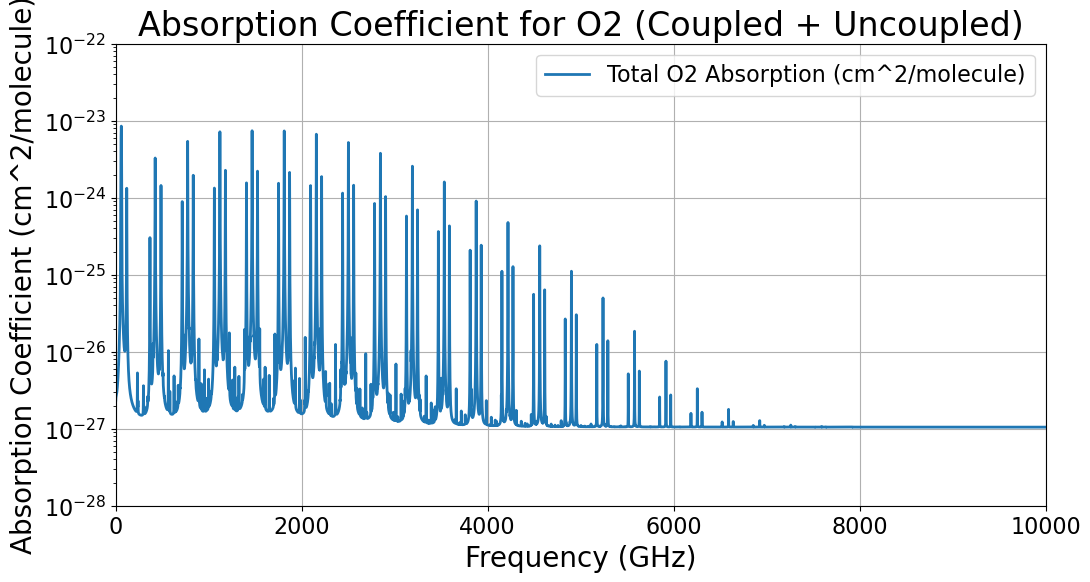

In [8]:
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

#Let's modify k_tot so that it doesn't go below 1e-26 to avoid plotting issues on the log scale
k_total_o2_graph = np.maximum(k_total_o2, 1e-27)
#Let's plot k_total_O2 vs frequency
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, k_total_o2, label='Total O2 Absorption (cm^2/molecule)', linewidth = 2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^2/molecule)')
plt.title('Absorption Coefficient for O2 (Coupled + Uncoupled)')
plt.xlim(0, 10000)
plt.yscale('log')
plt.ylim(1e-28, 1e-22)
plt.legend()
plt.grid()
plt.show()

Let's compare with pycraf

In [9]:
import jax.numpy as jnp

# ==============================================================================
# ITU-R P.676 Table 1: Oxygen Spectroscopic Data
# ==============================================================================
O2_f0 = jnp.array([50.474214, 50.987745, 51.50336, 52.021429, 52.542418, 53.066934, 53.595775, 54.130025, 54.67118, 55.221384, 55.783815, 56.264774, 56.363399, 56.968211, 57.612486, 58.323877, 58.446588, 59.164204, 59.590983, 60.306056, 60.434778, 61.150562, 61.800158, 62.41122, 62.486253, 62.997984, 63.568526, 64.127775, 64.67891, 65.224078, 65.764779, 66.302096, 66.836834, 67.369601, 67.900868, 68.431006, 68.960312, 118.750334, 368.498246, 424.76302, 487.249273, 715.392902, 773.83949, 834.145546])
O2_a1 = jnp.array([0.975, 2.529, 6.193, 14.32, 31.24, 64.29, 124.6, 227.3, 389.7, 627.1, 945.3, 543.4, 1331.8, 1746.6, 2120.1, 2363.7, 1442.1, 2379.9, 2090.7, 2103.4, 2438.0, 2479.5, 2275.9, 1915.4, 1503.0, 1490.2, 1078.0, 728.7, 461.3, 274.0, 153.0, 80.4, 39.8, 18.56, 8.172, 3.397, 1.334, 940.3, 67.4, 637.7, 237.4, 98.1, 572.3, 183.1])
O2_a2 = jnp.array([9.651, 8.653, 7.709, 6.819, 5.983, 5.201, 4.474, 3.8, 3.182, 2.618, 2.109, 0.014, 1.654, 1.255, 0.91, 0.621, 0.083, 0.387, 0.207, 0.207, 0.386, 0.621, 0.91, 1.255, 0.083, 1.654, 2.108, 2.617, 3.181, 3.8, 4.473, 5.2, 5.982, 6.818, 7.708, 8.652, 9.65, 0.01, 0.048, 0.044, 0.049, 0.145, 0.141, 0.145])
O2_a3 = jnp.array([6.69, 7.17, 7.64, 8.11, 8.58, 9.06, 9.55, 9.96, 10.37, 10.89, 11.34, 17.03, 11.89, 12.23, 12.62, 12.95, 14.91, 13.53, 14.08, 14.15, 13.39, 12.92, 12.63, 12.17, 15.13, 11.74, 11.34, 10.88, 10.38, 9.96, 9.55, 9.06, 8.58, 8.11, 7.64, 7.17, 6.69, 16.64, 16.4, 16.4, 16.0, 16.0, 16.2, 14.7])
O2_a4 = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a5 = jnp.array([2.566, 2.246, 1.947, 1.667, 1.388, 1.349, 2.227, 3.17, 3.558, 2.56, -1.172, 3.525, -2.378, -3.545, -5.416, -1.932, 6.768, -6.561, 6.957, -6.395, 6.342, 1.014, 5.014, 3.029, -4.499, 1.856, 0.658, -3.036, -3.968, -3.528, -2.548, -1.66, -1.68, -1.956, -2.216, -2.492, -2.773, -0.439, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a6 = jnp.array([6.85, 6.8, 6.729, 6.64, 6.526, 6.206, 5.085, 3.75, 2.654, 2.952, 6.135, -0.978, 6.547, 6.451, 6.056, 0.436, -1.273, 2.309, -0.776, 0.699, -2.825, -0.584, -6.619, -6.759, 0.844, -6.675, -6.139, -2.895, -2.59, -3.68, -5.002, -6.091, -6.393, -6.475, -6.545, -6.6, -6.65, 0.079, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

O2_DATA = {
    'f0': O2_f0, 'a1': O2_a1, 'a2': O2_a2, 
    'a3': O2_a3, 'a4': O2_a4, 'a5': O2_a5, 'a6': O2_a6
}

# ==============================================================================
# ITU-R P.676 Table 2: Water Vapor Spectroscopic Data
# ==============================================================================
H2O_f0 = jnp.array([22.23508, 67.80396, 119.99594, 183.310091, 321.225644, 325.152919, 336.222601, 380.197372, 390.134508, 437.346667, 439.150812, 443.018295, 448.001075, 470.888947, 474.689127, 488.491133, 503.568532, 504.482692, 547.67644, 552.02096, 556.936002, 620.700807, 645.866155, 658.00528, 752.033227, 841.053973, 859.962313, 899.306675, 902.616173, 906.207325, 916.171582, 923.118427, 970.315022, 987.926764, 1780.0])
H2O_b1 = jnp.array([0.113, 0.0012, 0.0008, 2.42, 0.0483, 1.499, 0.0011, 11.52, 0.0046, 0.065, 0.9218, 0.1976, 10.32, 0.3297, 1.262, 0.252, 0.039, 0.013, 9.701, 14.77, 487.4, 5.012, 0.0713, 0.3022, 239.6, 0.014, 0.1472, 0.0605, 0.0426, 0.1876, 8.34, 0.0869, 8.972, 132.1, 22300.0])
H2O_b2 = jnp.array([2.143, 8.735, 8.356, 0.668, 6.181, 1.54, 9.829, 1.048, 7.35, 5.05, 3.596, 5.05, 1.405, 3.599, 2.381, 2.853, 6.733, 6.733, 0.114, 0.114, 0.159, 2.2, 8.58, 7.82, 0.396, 8.18, 7.989, 7.917, 8.432, 5.111, 1.442, 10.22, 1.92, 0.258, 0.952])
H2O_b3 = jnp.array([28.11, 28.58, 29.48, 30.5, 23.03, 27.83, 26.93, 28.73, 21.52, 18.45, 21.0, 18.6, 26.32, 21.52, 23.55, 26.02, 16.12, 16.12, 26.0, 26.0, 32.1, 24.38, 18.0, 32.1, 30.6, 15.9, 30.6, 29.85, 28.65, 24.08, 26.7, 29.0, 25.5, 29.85, 176.2])
H2O_b4 = jnp.array([0.69, 0.69, 0.7, 0.64, 0.67, 0.68, 0.69, 0.54, 0.63, 0.6, 0.63, 0.6, 0.66, 0.66, 0.65, 0.69, 0.61, 0.61, 0.7, 0.7, 0.69, 0.71, 0.6, 0.69, 0.68, 0.33, 0.68, 0.68, 0.7, 0.7, 0.7, 0.7, 0.64, 0.68, 0.5])
H2O_b5 = jnp.array([4.8, 4.93, 4.78, 5.3, 4.69, 4.85, 4.74, 5.38, 4.81, 4.23, 4.29, 4.23, 4.84, 4.57, 4.65, 5.04, 3.98, 4.01, 4.5, 4.5, 4.11, 4.68, 4.0, 4.14, 4.09, 5.76, 4.09, 4.53, 5.1, 4.7, 4.78, 5.0, 4.94, 4.55, 30.5])
H2O_b6 = jnp.array([1.0, 0.82, 0.79, 0.85, 0.54, 0.74, 0.61, 0.89, 0.55, 0.48, 0.52, 0.5, 0.67, 0.65, 0.64, 0.72, 0.43, 0.45, 1.0, 1.0, 1.0, 0.68, 0.5, 1.0, 0.84, 0.45, 0.84, 0.9, 0.95, 0.53, 0.78, 0.8, 0.67, 0.9, 5.0])

H2O_DATA = {
    'f0': H2O_f0, 'b1': H2O_b1, 'b2': H2O_b2, 
    'b3': H2O_b3, 'b4': H2O_b4, 'b5': H2O_b5, 'b6': H2O_b6
}




import jax
import jax.numpy as jnp
from functools import partial

# Import the pre-loaded ITU constants we generated from the CSVs
#from .itu_constants import O2_DATA, H2O_DATA

# ==============================================================================
# 1. Point-wise Physics Core (ITU-R P.676-13 Annex 1)
# ==============================================================================

def compute_attenuation_point(T, P, e, freqs_GHz, o2_data, h2o_data):
    """
    Computes the specific attenuation for a single spatial point over multiple frequencies.
    Input scalars: T (Kelvin), P (hPa, dry air pressure), e (hPa, water vapor pressure).
    Input vector: freqs_GHz (shape: Nf,)
    Returns: gamma_dry, gamma_wet (both shape: Nf,)
    """
    # Expand freqs for matrix broadcasting against spectral lines
    # f shape: (Nf, 1)
    f = freqs_GHz[:, None] 
    
    # Temperature parameter
    theta = 300.0 / T
    
    # --- Oxygen Calculation ---
    f_o2 = o2_data['f0'][None, :] # Shape: (1, N_o2_lines), frequency of each oxygen line
    
    # Line strength
    S_o2 = o2_data['a1'] * 1e-7 * P * (theta**3) * jnp.exp(o2_data['a2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Zeeman broadening
    df_o2 = o2_data['a3'] * 1e-4 * (P * (theta**(0.8 - o2_data['a4'])) + 1.1 * e * theta) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_o2 = jnp.sqrt(df_o2**2 + 2.25e-6) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Interference factor
    delta_o2 = (o2_data['a5'] + o2_data['a6'] * theta) * 1e-4 * (P + e) * (theta**0.8) # Eq (7) from ITU-R P.676-13 Annex 1
    
    # Line shape (Van Vleck-Weisskopf)
    num1 = df_o2 - delta_o2 * (f_o2 - f)
    den1 = (f_o2 - f)**2 + df_o2**2
    num2 = df_o2 - delta_o2 * (f_o2 + f)
    den2 = (f_o2 + f)**2 + df_o2**2
    F_o2 = (f / f_o2) * ((num1 / den1) + (num2 / den2)) # Eq (5) from ITU-R P.676-13 Annex 1
    
    # Sum over all lines (axis 1 collapses the lines, leaving shape Nf)
    N_pp_o2_lines = jnp.sum(S_o2 * F_o2, axis=1) # You sum over the lines
    
    # Dry Continuum (Debye spectrum + nitrogen attenuation)
    d = 5.6e-4 * (P + e) * (theta**0.8) #eq (9) from ITU-R P.676-13 Annex 1
    term1 = 6.14e-5 / (d * (1 + (freqs_GHz / d)**2))
    term2 = (1.4e-12 * P * (theta**1.5)) / (1 + 1.9e-5 * (freqs_GHz**1.5))
    N_pp_D = freqs_GHz * P * (theta**2) * (term1 + term2) # Eq (8) from ITU-R P.676-13 Annex 1
    
    gamma_dry = 0.1820 * freqs_GHz * (N_pp_o2_lines) #+ N_pp_D) # Eq (1) and (2a) from ITU-R P.676-13 Annex 1


    # --- Water Vapor Calculation ---
    f_h2o = h2o_data['f0'][None, :] #frequency of each water vapor line, shape: (1, N_h2o_lines)
    
    # Line strength
    S_h2o = h2o_data['b1'] * 1e-1 * e * (theta**3.5) * jnp.exp(h2o_data['b2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Doppler broadening
    df_h2o = h2o_data['b3'] * 1e-4 * (P * (theta**h2o_data['b4']) + h2o_data['b5'] * e * (theta**h2o_data['b6'])) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_h2o = 0.535 * df_h2o + jnp.sqrt(0.217 * (df_h2o**2) + (2.1316e-12 * (f_h2o**2)) / theta) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Line shape (interference factor delta is 0 for H2O)
    num1_w = df_h2o
    den1_w = (f_h2o - f)**2 + df_h2o**2
    num2_w = df_h2o
    den2_w = (f_h2o + f)**2 + df_h2o**2
    F_h2o = (f / f_h2o) * ((num1_w / den1_w) + (num2_w / den2_w)) # Eq (5) from ITU-R P.676-13 Annex 1, but with delt_H2O=0 for water vapor lines
    
    # Sum over all water vapor lines
    N_pp_h2o = jnp.sum(S_h2o * F_h2o, axis=1)
    
    gamma_wet = 0.1820 * freqs_GHz * N_pp_h2o # Eq (1) and (2b) from ITU-R P.676-13 Annex 1
    
    return gamma_dry, gamma_wet

In [10]:
gamma_dry = compute_attenuation_point(T, P, P_water, frequencies/1e9, O2_DATA, H2O_DATA)[0] # in dB/km and we don't consider water vapor for this test

from scipy import constants
n_air = P *100/ (constants.k * T) * 1e-6 # number density of air molecules [molecules/cm^3]
n_O2 = n_air * 0.2095  # number density of O2 molecules [molecules/cm^3]

gamma_dry_lines_am = n_O2 * k_total_o2 * 1e5 * 4.3429 # Convert from cm^2/molecule to m^2/molecule and then to dB/km

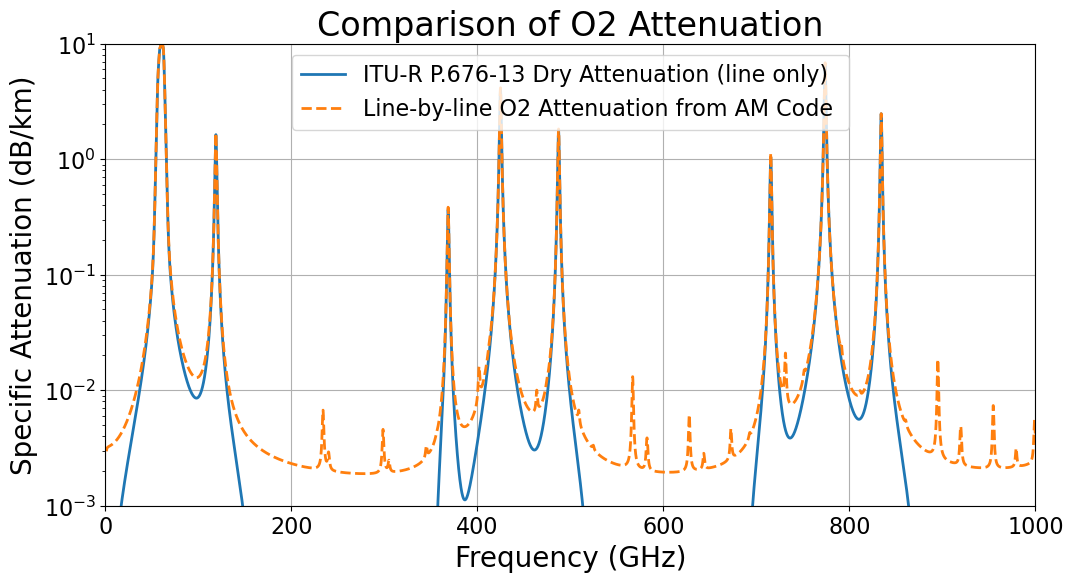

In [11]:
#Let's plot the comparison
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, gamma_dry, label='ITU-R P.676-13 Dry Attenuation (line only)', linewidth = 2)
plt.plot(frequencies * 1e-9, gamma_dry_lines_am, label='Line-by-line O2 Attenuation from AM Code ', linewidth = 2, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Specific Attenuation (dB/km)')
plt.title('Comparison of O2 Attenuation')
plt.xlim(0, 1000)
plt.ylim(1e-3, 1e1)
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

Let's get the continuum spectra by building the CIA am model for N2 and O2

In [12]:
import re
import numpy as np

def extract_ebc_pars(filepath, struct_name):
    """
    Extracts the A, B, C temperature coefficients from the cia.c EBCpars_t structs.
    """
    with open(filepath, 'r') as f:
        content = f.read()
    
    # 1. Find the specific struct block using regex
    pattern = rf"static const EBCpars_t {struct_name}\s*=\s*\{{([\s\S]*?)\}};"
    match = re.search(pattern, content)
    
    if not match:
        raise ValueError(f"Could not find {struct_name} in file.")
        
    block = match.group(1)
    
    # 2. Remove any C-style block comments /* ... */
    block_clean = re.sub(r'/\*.*?\*/', '', block, flags=re.DOTALL)
    
    # 3. Extract all valid floating point numbers
    numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", block_clean)
    floats = [float(n) for n in numbers]
    
    # 4. Map the numbers to the parameters
    # The struct is arranged as: runtime_val, A, B, C
    # So we skip the first number (index 0) and grab the next 3 (indices 1, 2, 3)
    pars = {}
    keys = ['S', 'tau1', 'tau2', 'eps', 'tau1p', 'tau2p']
    
    for i, key in enumerate(keys):
        idx = i * 4
        # Slice out the A, B, C values
        pars[key] = floats[idx+1 : idx+4]
        
    return pars

# --- Execution ---
cia_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/cia.c'

# Extract all three tables!
EBC3220_pars = extract_ebc_pars(cia_file_path, 'N2_EBC3220_INIT')
EBC5440_LT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_LT_INIT')
EBC5440_HT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_HT_INIT')

# Print one to verify
print("Extracted Quadrupolar (3220) Parameters:")
for key, abc in EBC3220_pars.items():
    print(f"{key:>5}: A={abc[0]:>11.5e}, B={abc[1]:>8.5f}, C={abc[2]:>8.5f}")

Extracted Quadrupolar (3220) Parameters:
    S: A=1.31362e-38, B=-3.79195, C= 0.33728
 tau1: A=1.29620e-03, B=-0.13048, C=-0.03128
 tau2: A=3.79690e-05, B= 1.03681, C=-0.14336
  eps: A=0.00000e+00, B= 0.00000, C= 0.00000
tau1p: A=0.00000e+00, B= 0.00000, C= 0.00000
tau2p: A=0.00000e+00, B= 0.00000, C= 0.00000


In [13]:
print("Extracted Quadrupolar (5440_HT) Parameters:")
for key, abc in EBC5440_HT_pars.items():
    print(f"{key:>5}: A={abc[0]:>11.5e}, B={abc[1]:>8.5f}, C={abc[2]:>8.5f}")

Extracted Quadrupolar (5440_HT) Parameters:
    S: A=1.07920e-43, B=-1.25562, C= 0.12981
 tau1: A=3.66110e-06, B= 1.47688, C=-0.16537
 tau2: A=6.12640e-01, B=-2.25011, C= 0.15289
  eps: A=3.00000e-01, B= 0.00000, C= 0.00000
tau1p: A=7.98200e-01, B=-2.76152, C= 0.21847
tau2p: A=5.28680e-13, B= 7.66253, C=-0.77527


In [14]:
def extract_ebc_pars(filepath, struct_name):
    """
    Robustly extracts the A, B, C coefficients from a named EBCpars_t struct
    by analyzing line-by-line rather than flattening all numbers.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    inside_struct = False
    extracted_rows = []
    
    # Track the lines belonging to our specific struct
    for line in lines:
        if f"static const EBCpars_t {struct_name}" in line:
            inside_struct = True
            continue
        if inside_struct:
            # Struct ends at };
            if "};" in line:
                inside_struct = False
                break
            # Clean comments and whitespace
            cleaned = re.sub(r'/\*.*?\*/', '', line)
            cleaned = re.sub(r'//.*$', '', cleaned).strip()
            if cleaned:
                extracted_rows.append(cleaned)
                
    # Map back to our keys
    keys = ['S', 'tau1', 'tau2', 'eps', 'tau1p', 'tau2p']
    pars = {}
    
    for i, key in enumerate(keys):
        # Grab the line corresponding to this parameter
        row_text = extracted_rows[i]
        
        # Extract all floats from this specific row
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", row_text)
        row_floats = [float(n) for n in numbers]
        
        # The structure is: [placeholder, A, B, C]
        # We save exactly [A, B, C]
        pars[key] = row_floats[1:4]
        
    return pars

# --- Execution ---
cia_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/cia.c'

# Extract all three tables!
EBC3220_pars = extract_ebc_pars(cia_file_path, 'N2_EBC3220_INIT')
EBC5440_LT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_LT_INIT')
EBC5440_HT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_HT_INIT')

# Print one to verify
print("Extracted Quadrupolar (3220) Parameters:")
for key, abc in EBC5440_HT_pars.items():
    print(f"{key:>5}: A={abc[0]:>11.5e}, B={abc[1]:>8.5f}, C={abc[2]:>8.5f}")

Extracted Quadrupolar (3220) Parameters:
    S: A=1.07920e-43, B=-1.25562, C= 0.12981
 tau1: A=3.66110e-06, B= 1.47688, C=-0.16537
 tau2: A=6.12640e-01, B=-2.25011, C= 0.15289
  eps: A=3.00000e-01, B= 0.00000, C= 0.00000
tau1p: A=7.98200e-01, B=-2.76152, C= 0.21847
tau2p: A=5.28680e-13, B= 7.66253, C=-0.77527


In [15]:
def compute_EBC_parameters(T, mechanism):
    """
    Computes the temperature-scaled line shape parameters (A * exp(B*lnT + C*lnT^2)).
    """
    if mechanism == "3220":
        pars = EBC3220_pars
    elif mechanism == "5440":
        # The hexadecapolar mechanism uses different tables based on temperature
        pars = EBC5440_LT_pars if T <= 140.0 else EBC5440_HT_pars
    else:
        raise ValueError("Mechanism must be '3220' or '5440'")

    #Here we change it to log10 to test it
    #lnT = np.log10(T) # Log base 10!
    #lnT_sq = lnT**2
    lnT = np.log(T) # Natural log!
    lnT_sq = lnT**2
    
    scaled_params = {}
    
    for key, coeffs in pars.items():
        A, B, C = coeffs
        
        # If A is 0, the whole term is 0 (handles the pure BC profile efficiently)
        if A == 0.0:
            scaled_params[key] = 0.0
        else:
            scaled_params[key] = A * np.exp(B * lnT + C * lnT_sq)
            
    return scaled_params

# Example for our 260K atmospheric layer
T_ambient = 260.0
params_quad = compute_EBC_parameters(T_ambient, "3220")

In [16]:
print("\nTemperature-scaled Quadrupolar (3220) Parameters at T=260K:")
for key, value in params_quad.items():
    print(f"{key:>5}: {value:>11.5e}")


Temperature-scaled Quadrupolar (3220) Parameters at T=260K:
    S: 3.09250e-43
 tau1: 2.38512e-04
 tau2: 1.43923e-04
  eps: 0.00000e+00
tau1p: 0.00000e+00
tau2p: 0.00000e+00


In [17]:
import numpy as np
from scipy import constants
from scipy.special import k0, k1

def compute_tau0_ns(T):
    """
    Computes the quantum time constant tau_0 = hbar / (2 * k_B * T) in nanoseconds.
    """
    tau0_seconds = constants.hbar / (2.0 * constants.k * T)
    tau0_ns = tau0_seconds * 1e9  # Convert to nanoseconds
    return tau0_ns

def birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2):
    """
    Computes the Birnbaum-Cohen (BC) translational line shape for Quadrupolar induction.
    nu_detuning_GHz: Array of frequencies (nu - nu_jj') [GHz]
    """
    # Prevent division by zero if parameters are missing
    if tau1 == 0.0 or tau2 == 0.0:
        return np.zeros_like(nu_detuning_GHz)
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The Exponential Term (Detailed Balance & Asymmetry)
    # Note: nu_detuning can be negative! This naturally shifts the profile.
    exp_term = np.exp((tau1 / tau2) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
    
    # 2. The z argument for the Bessel function
    nu_term = 1.0 + (2.0 * np.pi * nu_detuning_GHz * tau1)**2
    z = (np.sqrt(tau0**2 + tau2**2) / tau1) * np.sqrt(nu_term)
    
    # 3. Assemble the Gamma_BC profile
    prefactor = tau1 / np.pi
    bessel_term = (z * k1(z)) / nu_term
    
    Gamma_BC = prefactor * exp_term * bessel_term
    return Gamma_BC

def extended_birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2, eps, tau1p, tau2p):
    """
    Computes the Extended Birnbaum-Cohen (EBC) shape for Hexadecapolar induction.
    """
    # Base BC profile
    Gamma_BC = birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2)
    
    if eps == 0.0 or tau1p == 0.0 or tau2p == 0.0:
        return Gamma_BC
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The K0 Profile
    exp_term_K0 = np.exp((tau1p / tau2p) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
    z_prime = (np.sqrt(tau0**2 + tau2p**2) / tau2p) * np.sqrt(1.0 + (2.0 * np.pi * nu_detuning_GHz * tau2p)**2)
    
    Gamma_K0 = (tau1p / np.pi) * exp_term_K0 * k0(z_prime)
    
    # 2. Mix them using epsilon
    Gamma_EBC = (1.0 / (1.0 + eps)) * (Gamma_BC + eps * Gamma_K0)
    return Gamma_EBC

In [18]:
import numpy as np
from scipy import constants

# --- Core Molecular Constants (from cia.c) ---
CIA_MOL = {
    'N2': {
        'B': 59.6459,       # GHz
        'D': 1.727e-4,      # GHz
        'j_max': 30         # Maximum rotational state
    },
    'O2': {
        'B': 43.1004438,    # GHz
        'D': 1.45115e-4,    # GHz
        'j_max': 35         # Maximum rotational state
    }
}


def compute_energy_h_GHz(j, molecule):
    """
    Computes the rotational energy level E_j / h in GHz.
    Equation 4.8 from the am manual.
    """
    B = CIA_MOL[molecule]['B']
    D = CIA_MOL[molecule]['D']
    
    # E_j/h = B*j*(j+1) - D*j^2*(j+1)^2
    # Note: The manual writes + D, but D is usually a centrifugal distortion 
    # subtracted from the rigid rotor. In am's cia.c, it is mathematically B*x + D*x^2.
    x = j * (j + 1)
    return (B * x) + (D * x**2)

def get_gj(j, molecule):
    """
    Returns the nuclear spin statistical weight for state j.
    Equations 4.11 and 4.20 from the am manual.
    """
    if molecule == 'N2':
        # N2: 6 for even j, 3 for odd j
        return 6.0 if j % 2 == 0 else 3.0
    elif molecule == 'O2':
        # O2: 0 for even j (forbidden), 1 for odd j
        return 0.0 if j % 2 == 0 else 1.0
    else:
        raise ValueError("Molecule must be 'N2' or 'O2'")



def compute_populations(T, molecule):
    """
    Computes the Boltzmann population probability P_j(T) for initial states up to j_max,
    computing the energy grid up to j_max + 4 to allow for hexadecapolar jumps.
    """
    j_max = CIA_MOL[molecule]['j_max']
    max_j_prime = j_max + 4  # Accommodate the +4 quantum jump
    
    # 1. Compute energies up to the highest possible destination state
    j_energy_array = np.arange(max_j_prime + 1)
    E_j_h_array = np.zeros(max_j_prime + 1)
    for j in j_energy_array:
        E_j_h_array[j] = compute_energy_h_GHz(j, molecule)
        
    # 2. Compute populations ONLY up to j_max (the initial states)
    g_j_array = np.zeros(j_max + 1)
    for j in range(j_max + 1):
        g_j_array[j] = get_gj(j, molecule)
        
    # Convert E_j/h [GHz] to E_j / (k_B * T) [dimensionless]
    E_j_Joules = constants.h * (E_j_h_array[:j_max + 1] * 1e9)
    kT_Joules = constants.k * T
    dimensionless_energy = E_j_Joules / kT_Joules
    
    # Calculate the unnormalized Boltzmann terms
    boltzmann_terms = g_j_array * np.exp(-dimensionless_energy)
    
    # --- THE FIX: Add the (2j+1) spatial degeneracy to the partition sum! ---
    degeneracy_2j_plus_1 = 2 * np.arange(j_max + 1) + 1
    Q_T = np.sum(degeneracy_2j_plus_1 * boltzmann_terms)
    
    # Final Probability P_j(T)
    P_j = boltzmann_terms / Q_T
    
    return P_j, E_j_h_array

# Let's test it to see the states at 260K!
T_ambient = 260.0
P_j_N2, E_j_h_N2 = compute_populations(T_ambient, 'N2')

# Print the highest probability states for N2
most_populated_j = np.argmax(P_j_N2)
print(f"At {T_ambient}K, the most populated N2 state is j={most_populated_j} (P_j = {P_j_N2[most_populated_j]:.4f})")

At 260.0K, the most populated N2 state is j=0 (P_j = 0.0146)


In [19]:
import math

def clebsch_squared(j, lam, j_prime):
    """
    Computes the square of the Clebsch-Gordan coefficient C(j, lam, j'; 0, 0)^2.
    This acts as the quantum selection rule filter for rototranslational CIA.
    """
    # 1. The Triangle Rule (Angular Momentum Conservation)
    # The final spin state must be reachable by combining j and lambda.
    if j_prime < abs(j - lam) or j_prime > j + lam:
        return 0.0
        
    # 2. The Parity Rule (Symmetry Conservation)
    # For m1=m2=m3=0, the sum of the angular momenta MUST be even.
    J = j + lam + j_prime
    if J % 2 != 0:
        return 0.0
        
    # 3. Wigner 3-j Evaluation (Zero-Projection Simplification)
    g = J // 2
    
    # Pre-calculate the factorial blocks
    # Since j_max = 35 and lam = 4, the maximum J is 78. 
    # math.factorial handles n < 100 instantly with perfect precision.
    f_2g_2j   = math.factorial(2 * g - 2 * j)
    f_2g_2lam = math.factorial(2 * g - 2 * lam)
    f_2g_2jp  = math.factorial(2 * g - 2 * j_prime)
    f_2g_1    = math.factorial(2 * g + 1)
    
    # The squared factorial bracket term
    bracket_num = math.factorial(g)
    bracket_den = math.factorial(g - j) * math.factorial(g - lam) * math.factorial(g - j_prime)
    bracket_sq = (bracket_num / bracket_den) ** 2
    
    # Calculate the square of the Wigner 3-j symbol
    wigner_sq = (f_2g_2j * f_2g_2lam * f_2g_2jp / f_2g_1) * bracket_sq
    
    # 4. Convert Wigner 3-j Squared to Clebsch-Gordan Squared
    # Relationship: C^2 = (2*j_prime + 1) * Wigner3j^2
    cg_sq = (2 * j_prime + 1) * wigner_sq
    
    return float(cg_sq)

In [20]:
print(clebsch_squared(0, 2, 2))  # Returns 1.0 (100% geometric probability)
print(clebsch_squared(0, 2, 1))  # Returns 0.0 (Forbidden by Triangle/Parity)
print(clebsch_squared(0, 2, 3))  # Returns 0.0 (Forbidden by Triangle Rule)

1.0
0.0
0.0


In [21]:
print(clebsch_squared(2, 4, 6))  # Returns ~0.428 (Absorption jump of +4)
print(clebsch_squared(2, 4, 2))  # Returns ~0.285 (Elastic scattering jump of 0)
print(clebsch_squared(2, 4, 1))  # Returns 0.0 (Forbidden by Parity Rule)

0.4545454545454546
0.2857142857142857
0.0


In [22]:
import numpy as np
from scipy import constants

def calculate_cia_band(nu_grid_GHz, T, molecule):
    """
    Computes the complete rototranslational CIA binary absorption coefficient [cm^5]
    for either N2-N2 or O2-O2 homogeneous collisions.
    """
    # 1. Fundamental constants
    kT_Joules = constants.k * T
    h_Joules = constants.h
    
    # 2. Get the temperature-scaled parameters for both mechanisms
    pars_quad = compute_EBC_parameters(T, "3220")
    pars_hex  = compute_EBC_parameters(T, "5440")
    
    # 3. Apply O2-O2 empirical scaling (Manual Section 4.1.3)
    if molecule == 'O2':
        pars_quad['S'] *= 0.074
        pars_hex['S']  *= 2.45
        
    # 4. Compute populations and energy levels
    P_j, E_j_h = compute_populations(T, molecule)
    j_max = CIA_MOL[molecule]['j_max']
    
    # 5. Initialize the total binary absorption coefficient array
    k_b_total = np.zeros_like(nu_grid_GHz)
    
    # ---------------------------------------------------------
    # 6. THE DOUBLE-SUMMATION LOOP
    # ---------------------------------------------------------
    max_j_prime = j_max + 4 # To prevent index out-of-bounds
    
    for j in range(j_max + 1):
        # Skip states with zero probability (like even j for O2)
        if P_j[j] == 0.0:
            continue
            
        # A. Quadrupolar Transitions (lambda = 2)
        # Explicitly only check the allowed jumps: -2, 0, +2
        for delta_j in [-2, 0, 2]:
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 2, j_prime)
            
            if cg_sq > 0.0:
                # FIX 1: Photon energy equals the positive energy gap!
                nu_jj_prime = E_j_h[j_prime] - E_j_h[j]
                nu_detuning = nu_grid_GHz - nu_jj_prime
                
                Gamma_BC = birnbaum_cohen_shape(
                    nu_detuning, T, pars_quad['tau1'], pars_quad['tau2']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_quad['S'] * weight * Gamma_BC

        # B. Hexadecapolar Transitions (lambda = 4)
        # Explicitly only check allowed jumps: -4, -2, 0, +2, +4
        for delta_j in [-4, -2, 0, 2, 4] :
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 4, j_prime)
            
            if cg_sq > 0.0:
                # FIX 1: Photon energy equals the positive energy gap!
                nu_jj_prime = E_j_h[j_prime] - E_j_h[j]
                nu_detuning = nu_grid_GHz - nu_jj_prime
                
                Gamma_EBC = extended_birnbaum_cohen_shape(
                    nu_detuning, T, 
                    pars_hex['tau1'], pars_hex['tau2'], pars_hex['eps'], 
                    pars_hex['tau1p'], pars_hex['tau2p']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_hex['S'] * weight * Gamma_EBC

    # ---------------------------------------------------------
    # 7. THE RADIATION TERM (Detailed Balance)
    # ---------------------------------------------------------
    # Equation 4.5 & 4.6: nu * (1 - exp(-h * nu / kT))
    nu_Hz = nu_grid_GHz * 1e9
    radiation_term = nu_grid_GHz * (1.0 - np.exp(-h_Joules * nu_Hz / kT_Joules))
    
    # Final assembly
    k_b_total = k_b_total * radiation_term
    
    return k_b_total

In [81]:
import numpy as np
from scipy import constants
from scipy.special import k0, k1

def compute_tau0_ns(T):
    """
    Computes the quantum time constant tau_0 = hbar / (2 * k_B * T) in nanoseconds.
    """
    tau0_seconds = constants.hbar / (2.0 * constants.k * T)
    tau0_ns = tau0_seconds * 1e9  # Convert to nanoseconds
    return tau0_ns

def birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2):
    """
    Computes the Birnbaum-Cohen (BC) translational line shape for Quadrupolar induction.
    nu_detuning_GHz: Array of frequencies (nu - nu_jj') [GHz]
    """
    # Prevent division by zero if parameters are missing
    if tau1 == 0.0 or tau2 == 0.0:
        return np.zeros_like(nu_detuning_GHz)
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The Exponential Term (Detailed Balance & Asymmetry)
    # Note: nu_detuning can be negative! This naturally shifts the profile.
    exp_term = np.exp((tau2 / tau1) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
    
    # 2. The z argument for the Bessel function
    nu_term = 1.0 + (2.0 * np.pi * nu_detuning_GHz * tau1)**2
    z = (np.sqrt(tau0**2 + tau2**2) / tau1) * np.sqrt(nu_term)
    
    # 3. Assemble the Gamma_BC profile
    prefactor = tau1 / np.pi
    bessel_term = (z * k1(z)) / nu_term
    
    Gamma_BC = prefactor * exp_term * bessel_term
    return Gamma_BC

def extended_birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2, eps, tau1p, tau2p):
    """
    Computes the Extended Birnbaum-Cohen (EBC) shape for Hexadecapolar induction.
    """
    # Base BC profile
    Gamma_BC = birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2)
    
    if eps == 0.0 or tau1p == 0.0 or tau2p == 0.0:
        return Gamma_BC
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The K0 Profile
    exp_term_K0 = np.exp((tau1p / tau2p) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
   
    z_prime = (np.sqrt(tau0**2 + tau1p**2) / tau2p) * np.sqrt(1.0 + (2.0 * np.pi * nu_detuning_GHz * tau2p)**2)
    
    Gamma_K0 = (tau1p / np.pi) * exp_term_K0 * k0(z_prime)
    
    # 2. Mix them using epsilon
    Gamma_EBC = (1.0 / (1.0 + eps)) * (Gamma_BC + eps * Gamma_K0)
    return Gamma_EBC

import numpy as np
from scipy import constants

# --- Core Molecular Constants (from cia.c) ---
CIA_MOL = {
    'N2': {
        'B': 59.6459,       # GHz
        'D': 1.727e-4,      # GHz
        'j_max': 30         # Maximum rotational state
    },
    'O2': {
        'B': 43.1004438,    # GHz
        'D': 1.45115e-4,    # GHz
        'j_max': 35         # Maximum rotational state
    }
}


def compute_energy_h_GHz(j, molecule):
    """
    Computes the rotational energy level E_j / h in GHz.
    Equation 4.8 from the am manual.
    """
    B = CIA_MOL[molecule]['B']
    D = CIA_MOL[molecule]['D']
    
    # E_j/h = B*j*(j+1) - D*j^2*(j+1)^2
    # Note: The manual writes + D, but D is usually a centrifugal distortion 
    # subtracted from the rigid rotor. In am's cia.c, it is mathematically B*x + D*x^2.
    x = j * (j + 1)
    return (B * x) + (D * x**2)

def get_gj(j, molecule):
    """
    Returns the nuclear spin statistical weight for state j.
    Equations 4.11 and 4.20 from the am manual.
    """
    if molecule == 'N2':
        # N2: 6 for even j, 3 for odd j
        return 6.0 if j % 2 == 0 else 3.0
    elif molecule == 'O2':
        # O2: 0 for even j (forbidden), 1 for odd j
        return 0.0 if j % 2 == 0 else 1.0
    else:
        raise ValueError("Molecule must be 'N2' or 'O2'")



def compute_populations(T, molecule):
    """
    Computes the Boltzmann population probability P_j(T) for initial states up to j_max,
    computing the energy grid up to j_max + 4 to allow for hexadecapolar jumps.
    """
    j_max = CIA_MOL[molecule]['j_max']
    max_j_prime = j_max + 4  # Accommodate the +4 quantum jump
    
    # 1. Compute energies up to the highest possible destination state
    j_energy_array = np.arange(max_j_prime + 1)
    E_j_h_array = np.zeros(max_j_prime + 1)
    for j in j_energy_array:
        E_j_h_array[j] = compute_energy_h_GHz(j, molecule)
        
    # 2. Compute populations ONLY up to j_max (the initial states)
    g_j_array = np.zeros(j_max + 1)
    for j in range(j_max + 1):
        g_j_array[j] = get_gj(j, molecule)
        
    # Convert E_j/h [GHz] to E_j / (k_B * T) [dimensionless]
    E_j_Joules = constants.h * (E_j_h_array[:j_max + 1] * 1e9)
    kT_Joules = constants.k * T
    dimensionless_energy = E_j_Joules / kT_Joules
    
    # Calculate the unnormalized Boltzmann terms
    boltzmann_terms = g_j_array * np.exp(-dimensionless_energy)
    
    # --- THE FIX: Add the (2j+1) spatial degeneracy to the partition sum! ---
    degeneracy_2j_plus_1 = 2 * np.arange(j_max + 1) + 1
    Q_T = np.sum(degeneracy_2j_plus_1 * boltzmann_terms)
    
    # Final Probability P_j(T)
    P_j = boltzmann_terms / Q_T
    
    return P_j, E_j_h_array

import math

def clebsch_squared(j, lam, j_prime):
    """
    Computes the square of the Clebsch-Gordan coefficient C(j, lam, j'; 0, 0)^2.
    This acts as the quantum selection rule filter for rototranslational CIA.
    """
    # 1. The Triangle Rule (Angular Momentum Conservation)
    # The final spin state must be reachable by combining j and lambda.
    if j_prime < abs(j - lam) or j_prime > j + lam:
        return 0.0
        
    # 2. The Parity Rule (Symmetry Conservation)
    # For m1=m2=m3=0, the sum of the angular momenta MUST be even.
    J = j + lam + j_prime
    if J % 2 != 0:
        return 0.0
        
    # 3. Wigner 3-j Evaluation (Zero-Projection Simplification)
    g = J // 2
    
    # Pre-calculate the factorial blocks
    # Since j_max = 35 and lam = 4, the maximum J is 78. 
    # math.factorial handles n < 100 instantly with perfect precision.
    f_2g_2j   = math.factorial(2 * g - 2 * j)
    f_2g_2lam = math.factorial(2 * g - 2 * lam)
    f_2g_2jp  = math.factorial(2 * g - 2 * j_prime)
    f_2g_1    = math.factorial(2 * g + 1)
    
    # The squared factorial bracket term
    bracket_num = math.factorial(g)
    bracket_den = math.factorial(g - j) * math.factorial(g - lam) * math.factorial(g - j_prime)
    bracket_sq = (bracket_num / bracket_den) ** 2
    
    # Calculate the square of the Wigner 3-j symbol
    wigner_sq = (f_2g_2j * f_2g_2lam * f_2g_2jp / f_2g_1) * bracket_sq
    
    # 4. Convert Wigner 3-j Squared to Clebsch-Gordan Squared
    # Relationship: C^2 = (2*j_prime + 1) * Wigner3j^2
    cg_sq = (2 * j_prime + 1) * wigner_sq
    
    return float(cg_sq)

import numpy as np
from scipy import constants

def calculate_cia_band(nu_grid_GHz, T, molecule):
    """
    Computes the complete rototranslational CIA binary absorption coefficient [cm^5]
    for either N2-N2 or O2-O2 homogeneous collisions.
    """
    # 1. Fundamental constants
    kT_Joules = constants.k * T
    h_Joules = constants.h
    
    # 2. Get the temperature-scaled parameters for both mechanisms
    pars_quad = compute_EBC_parameters(T, "3220")
    pars_hex  = compute_EBC_parameters(T, "5440")
    
    # 3. Apply O2-O2 empirical scaling (Manual Section 4.1.3)
    if molecule == 'O2':
        pars_quad['S'] *= 0.074
        pars_hex['S']  *= 2.45
        
    # 4. Compute populations and energy levels
    P_j, E_j_h = compute_populations(T, molecule)
    j_max = CIA_MOL[molecule]['j_max']
    
    # 5. Initialize the total binary absorption coefficient array
    k_b_total = np.zeros_like(nu_grid_GHz)
    
    # ---------------------------------------------------------
    # 6. THE DOUBLE-SUMMATION LOOP
    # ---------------------------------------------------------
    max_j_prime = j_max + 4 # To prevent index out-of-bounds
    
    for j in range(j_max + 1):
        # Skip states with zero probability (like even j for O2)
        if P_j[j] == 0.0:
            continue
            
        # A. Quadrupolar Transitions (lambda = 2)
        # Explicitly only check the allowed jumps: -2, 0, +2
        for delta_j in [-2, 0, 2]:
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 2, j_prime)
            
            if cg_sq > 0.0:
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_BC = birnbaum_cohen_shape(
                    nu_detuning, T, pars_quad['tau1'], pars_quad['tau2']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_quad['S'] * weight * Gamma_BC

        # B. Hexadecapolar Transitions (lambda = 4)
        # Explicitly only check allowed jumps: -4, -2, 0, +2, +4
        for delta_j in [-4, -2, 0, 2, 4] :
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 4, j_prime)
            
            if cg_sq > 0.0:
                
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_EBC = extended_birnbaum_cohen_shape(
                    nu_detuning, T, 
                    pars_hex['tau1'], pars_hex['tau2'], pars_hex['eps'], 
                    pars_hex['tau1p'], pars_hex['tau2p']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_hex['S'] * weight * Gamma_EBC

    # ---------------------------------------------------------
    # 7. THE RADIATION TERM (Detailed Balance)
    # ---------------------------------------------------------
    # Equation 4.5 & 4.6: nu * (1 - exp(-h * nu / kT))
    nu_Hz = nu_grid_GHz * 1e9
    radiation_term = nu_grid_GHz * (1.0 - np.exp(-h_Joules * nu_Hz / kT_Joules))
    
    # Final assembly
    k_b_total = k_b_total * radiation_term
    
    return k_b_total

In [88]:
T_ambient = 228.3 # Kelvin

# Calculate the pure binary coefficients [cm^5]
kb_N2N2 = calculate_cia_band(freqs_GHz, T_ambient, 'N2')
kb_O2O2 = calculate_cia_band(freqs_GHz, T_ambient, 'O2')

# Calculate the mixed binary coefficients using am manual scalings
kb_N2O2 = 1.143 * kb_N2N2
kb_O2N2 = 0.822 * kb_O2O2

In [25]:
print(freqs_GHz.shape)

(100000,)


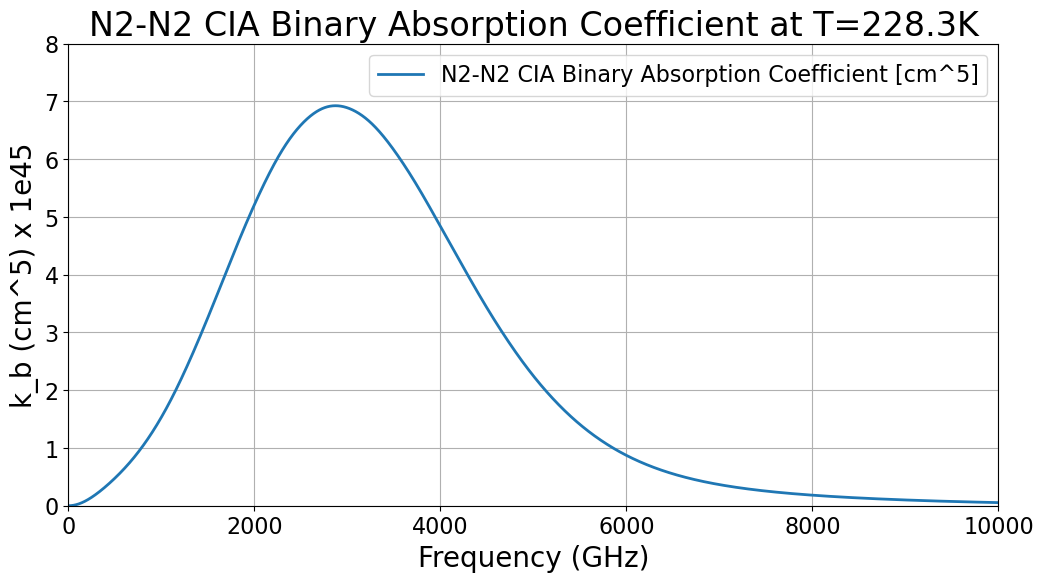

In [90]:
#Lets plot kb_N2N2 to see the shape
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, kb_N2N2*1e45, label='N2-N2 CIA Binary Absorption Coefficient [cm^5]', linewidth=2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('k_b (cm^5) x 1e45')
plt.title(f'N2-N2 CIA Binary Absorption Coefficient at T={T_ambient}K')
plt.xlim(0, 10000)
plt.ylim(0, 8)
#plt.ylim(1e-50, 1e-20)
#plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [85]:
kb_O2O2 = calculate_cia_band(freqs_GHz, 300, 'O2')

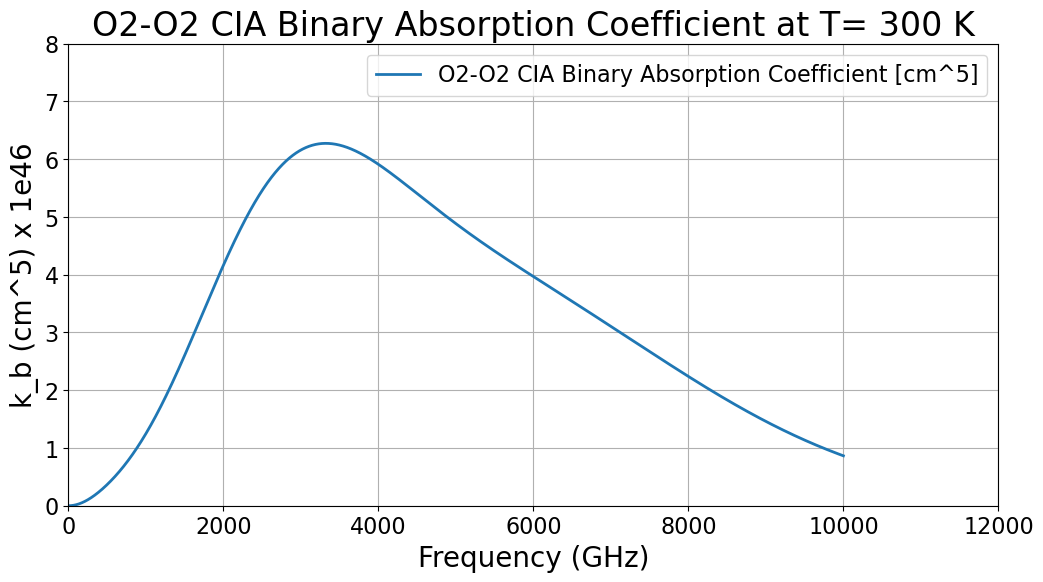

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, kb_O2O2*1e46, label='O2-O2 CIA Binary Absorption Coefficient [cm^5]', linewidth=2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('k_b (cm^5) x 1e46')
plt.title(f'O2-O2 CIA Binary Absorption Coefficient at T= 300 K')
plt.xlim(0, 12000)
plt.ylim ( 0, 8)
#plt.ylim(1e-50, 1e-20)
#plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [29]:
import jax
import jax.numpy as jnp
from functools import partial

# Import the pre-loaded ITU constants we generated from the CSVs
#from .itu_constants import O2_DATA, H2O_DATA

# ==============================================================================
# 1. Point-wise Physics Core (ITU-R P.676-13 Annex 1)
# ==============================================================================

def compute_attenuation_point_air_continuum(T, P, e, freqs_GHz, o2_data, h2o_data):
    """
    Computes the specific attenuation for a single spatial point over multiple frequencies.
    Input scalars: T (Kelvin), P (hPa, dry air pressure), e (hPa, water vapor pressure).
    Input vector: freqs_GHz (shape: Nf,)
    Returns: gamma_dry, gamma_wet (both shape: Nf,)
    """
    # Expand freqs for matrix broadcasting against spectral lines
    # f shape: (Nf, 1)
    f = freqs_GHz[:, None] 
    
    # Temperature parameter
    theta = 300.0 / T
    
    # --- Oxygen Calculation ---
    f_o2 = o2_data['f0'][None, :] # Shape: (1, N_o2_lines), frequency of each oxygen line
    
    # Line strength
    S_o2 = o2_data['a1'] * 1e-7 * P * (theta**3) * jnp.exp(o2_data['a2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Zeeman broadening
    df_o2 = o2_data['a3'] * 1e-4 * (P * (theta**(0.8 - o2_data['a4'])) + 1.1 * e * theta) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_o2 = jnp.sqrt(df_o2**2 + 2.25e-6) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Interference factor
    delta_o2 = (o2_data['a5'] + o2_data['a6'] * theta) * 1e-4 * (P + e) * (theta**0.8) # Eq (7) from ITU-R P.676-13 Annex 1
    
    # Line shape (Van Vleck-Weisskopf)
    num1 = df_o2 - delta_o2 * (f_o2 - f)
    den1 = (f_o2 - f)**2 + df_o2**2
    num2 = df_o2 - delta_o2 * (f_o2 + f)
    den2 = (f_o2 + f)**2 + df_o2**2
    F_o2 = (f / f_o2) * ((num1 / den1) + (num2 / den2)) # Eq (5) from ITU-R P.676-13 Annex 1
    
    # Sum over all lines (axis 1 collapses the lines, leaving shape Nf)
    N_pp_o2_lines = jnp.sum(S_o2 * F_o2, axis=1) # You sum over the lines
    
    # Dry Continuum (Debye spectrum + nitrogen attenuation)
    d = 5.6e-4 * (P + e) * (theta**0.8) #eq (9) from ITU-R P.676-13 Annex 1
    term1 = 6.14e-5 / (d * (1 + (freqs_GHz / d)**2))
    term2 = (1.4e-12 * P * (theta**1.5)) / (1 + 1.9e-5 * (freqs_GHz**1.5))
    N_pp_D = freqs_GHz * P * (theta**2) * (term1 + term2) # Eq (8) from ITU-R P.676-13 Annex 1
    
    gamma_dry = 0.1820 * freqs_GHz * N_pp_D #(N_pp_o2_lines) #+ N_pp_D) # Eq (1) and (2a) from ITU-R P.676-13 Annex 1


    # --- Water Vapor Calculation ---
    f_h2o = h2o_data['f0'][None, :] #frequency of each water vapor line, shape: (1, N_h2o_lines)
    
    # Line strength
    S_h2o = h2o_data['b1'] * 1e-1 * e * (theta**3.5) * jnp.exp(h2o_data['b2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Doppler broadening
    df_h2o = h2o_data['b3'] * 1e-4 * (P * (theta**h2o_data['b4']) + h2o_data['b5'] * e * (theta**h2o_data['b6'])) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_h2o = 0.535 * df_h2o + jnp.sqrt(0.217 * (df_h2o**2) + (2.1316e-12 * (f_h2o**2)) / theta) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Line shape (interference factor delta is 0 for H2O)
    num1_w = df_h2o
    den1_w = (f_h2o - f)**2 + df_h2o**2
    num2_w = df_h2o
    den2_w = (f_h2o + f)**2 + df_h2o**2
    F_h2o = (f / f_h2o) * ((num1_w / den1_w) + (num2_w / den2_w)) # Eq (5) from ITU-R P.676-13 Annex 1, but with delt_H2O=0 for water vapor lines
    
    # Sum over all water vapor lines
    N_pp_h2o = jnp.sum(S_h2o * F_h2o, axis=1)
    
    gamma_wet = 0.1820 * freqs_GHz * N_pp_h2o # Eq (1) and (2b) from ITU-R P.676-13 Annex 1
    
    return gamma_dry, gamma_wet

In [102]:
gamma_dry_continuum = compute_attenuation_point_air_continuum(T, P, 0, frequencies/1e9, O2_DATA, H2O_DATA)[0] # in dB/km and we don't consider water vapor for this test

# Calculate the pure binary coefficients [cm^5]
kb_N2N2 = calculate_cia_band(frequencies/1e9, T, 'N2')
kb_O2O2 = calculate_cia_band(frequencies/1e9, T, 'O2')

# Calculate the mixed binary coefficients using am manual scalings
kb_N2O2 = 1.143 * kb_N2N2
kb_O2N2 = 0.822 * kb_O2O2

from scipy import constants
n_air = P *100/ (constants.k * T) * 1e-6 # number density of air molecules [molecules/cm^3]
n_O2 = n_air * 0.2095  # number density of O2 molecules [molecules/cm^3]
n_N2 = n_air * 0.7808  # number density of N2 molecules [molecules/cm^3]

alpha_total_continuum_dry = n_O2 **2 * kb_O2O2 + n_N2 **2 * kb_N2N2 + n_O2 * n_N2 * (kb_N2O2 + kb_O2N2) # in cm^-1

gamma_dry_continuum_am = alpha_total_continuum_dry * 1e5 * 4.3429 # Convert from cm^2/molecule to m^2/molecule and then to dB/km

In [110]:
alpha_total_continuum_dry = n_N2 **2 * kb_N2N2 #+ n_O2 **2 * kb_O2O2 + 2 * n_O2 * n_N2 * (kb_N2O2 + kb_O2N2) # in cm^-1

gamma_dry_continuum_am = alpha_total_continuum_dry * 1e5 * 4.3429 # Convert from cm^2/molecul

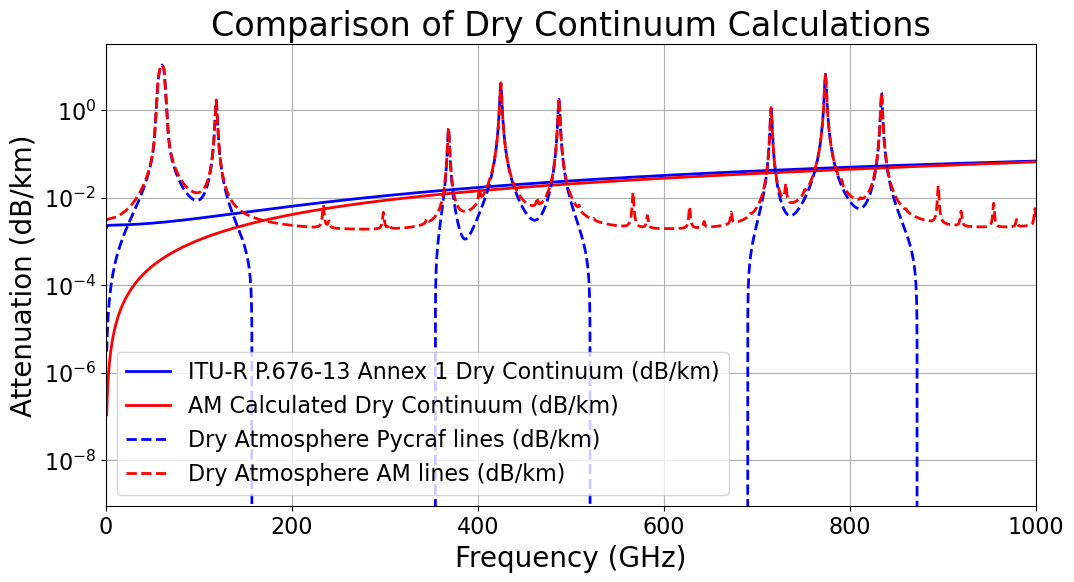

In [111]:
#Let's plot the results to compare with the ITU-R P.676-13 Annex 1 Figure 1
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, gamma_dry_continuum, label='ITU-R P.676-13 Annex 1 Dry Continuum (dB/km)', color = 'blue',  linewidth=2)
plt.plot(freqs_GHz, gamma_dry_continuum_am, label='AM Calculated Dry Continuum (dB/km)', color = 'red', linewidth=2,)
plt.plot(freqs_GHz, gamma_dry, label='Dry Atmosphere Pycraf lines (dB/km)', color = 'blue', linewidth=2, linestyle='dashed')
plt.plot(freqs_GHz, gamma_dry_lines_am, label='Dry Atmosphere AM lines (dB/km)', color = 'red', linewidth=2, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of Dry Continuum Calculations')
plt.legend()
plt.yscale('log')
plt.xlim(0, 1000)
plt.grid(True)
plt.show()

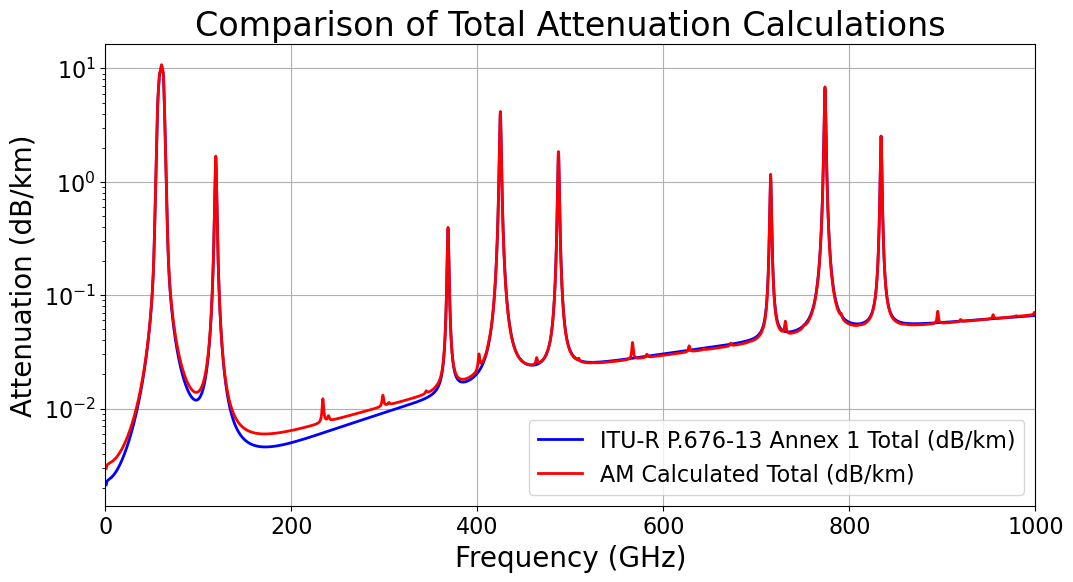

In [112]:
#Let's compare the full AM calculation (lines + continuum) with the ITU-R P.676-13 Annex 1 Figure 1
gamma_total_am = gamma_dry_continuum_am + gamma_dry_lines_am
gamma_total_itu = gamma_dry_continuum + gamma_dry
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, gamma_total_itu, label='ITU-R P.676-13 Annex 1 Total (dB/km)', color = 'blue',  linewidth=2)
plt.plot(freqs_GHz, gamma_total_am, label='AM Calculated Total (dB/km)', color = 'red', linewidth=2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of Total Attenuation Calculations')
plt.legend()
plt.yscale('log')
plt.xlim(0, 1000)
plt.grid(True)
plt.show()

In [60]:
# We'll look at the optical depth 

total_air_mass_per_unit_area = 5400 # in kg/m^2, typical order at atacama
print(f"Total air mass per unit area: {total_air_mass_per_unit_area:.2f} kg/m^2")

Total air mass per unit area: 5400.00 kg/m^2


In [61]:
rho_air = P * 100 / (T * 287.05) # using ideal gas law, where R = 287.05 J/(kg*K)

L = total_air_mass_per_unit_area / rho_air # in meters
print(f"Effective path length through the atmosphere: {L:.2f} meters")

Effective path length through the atmosphere: 8060.36 meters


In [113]:
tau_total_am = gamma_total_am / 4.3429 * L * 1e-3 # Convert from dB/km to dimensionless optical depth
tau_total_itu = gamma_total_itu / 4.3429 * L * 1e-3 # Convert from dB/km to dimensionless optical depth

T_b_am = T * ( 1 - np.exp(-tau_total_am)) # Brightness temperature from the AM calculation
T_b_itu = T * ( 1 - np.exp(-tau_total_itu)) # Brightness temperature from the ITU-R P.676-13 Annex 1 calculation

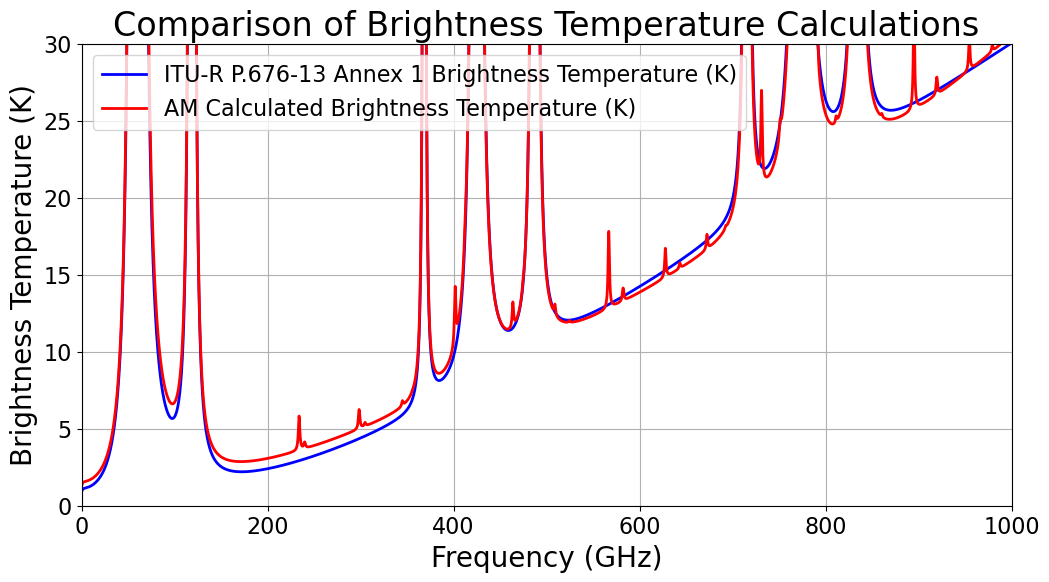

In [114]:
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, T_b_itu, label='ITU-R P.676-13 Annex 1 Brightness Temperature (K)', color = 'blue',  linewidth=2)
plt.plot(freqs_GHz, T_b_am, label='AM Calculated Brightness Temperature (K)', color = 'red', linewidth=2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')    
plt.title('Comparison of Brightness Temperature Calculations')
plt.legend()
plt.xlim(0, 1000)
plt.ylim(0,30)
plt.grid(True)
plt.show()

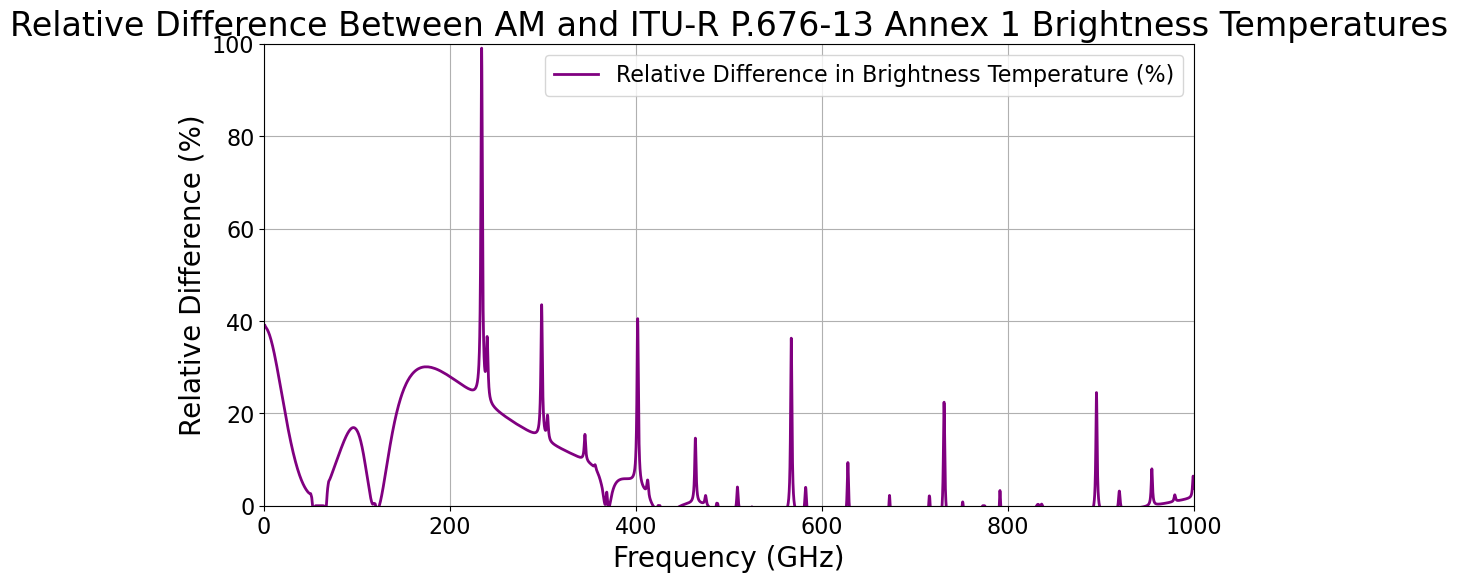

In [115]:
#Let's plot the relative difference in % 

plt.figure(figsize=(12, 6))
relative_difference = 100 * (T_b_am - T_b_itu) / T_b_itu
plt.plot(freqs_GHz, relative_difference, label='Relative Difference in Brightness Temperature (%)', color = 'purple', linewidth=2)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Relative Difference (%)')
plt.title('Relative Difference Between AM and ITU-R P.676-13 Annex 1 Brightness Temperatures')
plt.legend()
plt.xlim(0, 1000)
plt.ylim(0,100)
plt.grid(True)
plt.show()